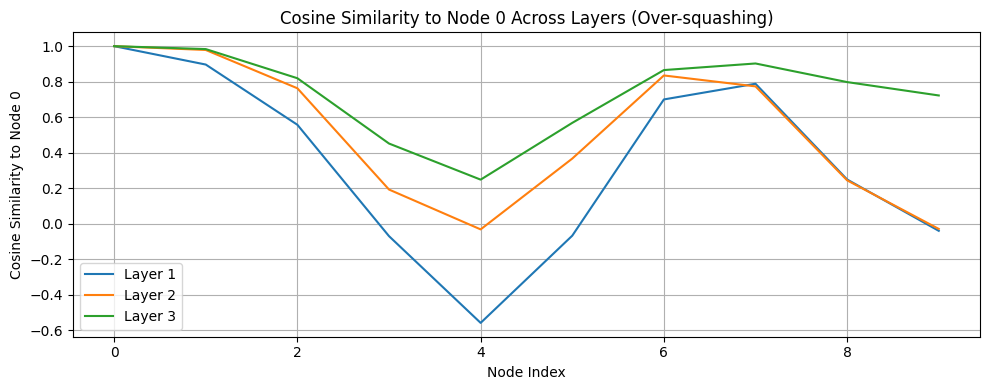

In [1]:
import torch
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# Create a chain graph with 10 nodes
edge_index = torch.tensor([
    [0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9],
    [1, 0, 2, 1, 3, 2, 4, 3, 5, 4, 6, 5, 7, 6, 8, 7, 9, 8]
], dtype=torch.long)

# Node features: use one-hot encoding for clarity
x = torch.eye(10)

# Create the graph
data = Data(x=x, edge_index=edge_index)

# Define a simple 3-layer GCN
class SimpleGCN(torch.nn.Module):
    def __init__(self):
        super(SimpleGCN, self).__init__()
        self.conv1 = GCNConv(10, 8)
        self.conv2 = GCNConv(8, 8)
        self.conv3 = GCNConv(8, 8)

    def forward(self, x, edge_index):
        x1 = self.conv1(x, edge_index).detach()
        x2 = self.conv2(x1, edge_index).detach()
        x3 = self.conv3(x2, edge_index).detach()
        return x1, x2, x3

# Instantiate and run the model
model = SimpleGCN()
with torch.no_grad():
    h1, h2, h3 = model(data.x, data.edge_index)

# Plot the activation similarity between node 0 and all other nodes
def cosine_similarity_matrix(node_embedding, node_idx=0):
    base = node_embedding[node_idx]
    sims = torch.nn.functional.cosine_similarity(base.unsqueeze(0), node_embedding)
    return sims.numpy()

sims_h1 = cosine_similarity_matrix(h1)
sims_h2 = cosine_similarity_matrix(h2)
sims_h3 = cosine_similarity_matrix(h3)

# Plot similarities
plt.figure(figsize=(10, 4))
plt.plot(sims_h1, label='Layer 1')
plt.plot(sims_h2, label='Layer 2')
plt.plot(sims_h3, label='Layer 3')
plt.title("Cosine Similarity to Node 0 Across Layers (Over-squashing)")
plt.xlabel("Node Index")
plt.ylabel("Cosine Similarity to Node 0")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
